<a href="https://colab.research.google.com/github/vanessalugo04/Procesamiento_lenguaje_natural/blob/main/Practica_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRACTICA 7.

## a) Retomando One hot encoding, BoW y Matriz de coocurrencia, aplica PSA y TSNe para por medio de un corpus de 700 palabras como minimo responder : ¿cómo se puede determinar cual reduce mejor la dimensión?



In [1]:
# importamos las librerias necesarias
import pandas as pd
import numpy as np

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# El corpus - texto de más de 1200 palabras sobre IA
# Lo definimos como un solo string largo y luego lo dividimos
#  en 3 "documentos" para poder usar Bag of Words

doc1 = """
La inteligencia artificial es una rama de la informática que busca crear sistemas
capaces de realizar tareas que normalmente requieren inteligencia humana. Entre estas
tareas se encuentran el reconocimiento de voz, la visión por computadora, la toma de
decisiones y la traducción de idiomas. La inteligencia artificial ha evolucionado
enormemente desde sus inicios en la década de 1950, cuando Alan Turing propuso la
famosa prueba que lleva su nombre para evaluar si una máquina puede exhibir un
comportamiento inteligente indistinguible del de un ser humano. Desde entonces, los
avances en hardware, software y disponibilidad de datos han permitido que la
inteligencia artificial pase de ser una idea teórica a una tecnología presente en
nuestra vida cotidiana. Los asistentes virtuales, los sistemas de recomendación y los
vehículos autónomos son ejemplos claros de cómo la inteligencia artificial transforma
industrias enteras. El aprendizaje automático es una subdisciplina de la inteligencia
artificial que permite a las máquinas aprender de los datos sin ser programadas
explícitamente. Los algoritmos de aprendizaje automático identifican patrones en
grandes conjuntos de datos y utilizan esos patrones para hacer predicciones o tomar
decisiones. Existen tres tipos principales de aprendizaje automático: supervisado,
no supervisado y por refuerzo. En el aprendizaje supervisado, el modelo se entrena
con datos etiquetados, es decir, ejemplos donde la respuesta correcta ya es conocida.
En el aprendizaje no supervisado, el modelo busca estructuras ocultas en datos sin
etiquetar. En el aprendizaje por refuerzo, un agente aprende a tomar decisiones
interactuando con un entorno y recibiendo recompensas o penalizaciones.
"""

doc2 = """
Las redes neuronales artificiales son modelos computacionales inspirados en la
estructura del cerebro humano. Están formadas por capas de nodos o neuronas
artificiales conectadas entre sí mediante pesos que se ajustan durante el
entrenamiento. El aprendizaje profundo es una técnica de aprendizaje automático
basada en redes neuronales con muchas capas ocultas. Estas redes profundas han
demostrado resultados extraordinarios en tareas como el reconocimiento de imágenes,
el procesamiento del lenguaje natural y la generación de contenido. El procesamiento
del lenguaje natural es el campo de la inteligencia artificial que se ocupa de la
interacción entre computadoras y lenguaje humano. Mediante técnicas como la
tokenización, el análisis sintáctico y los modelos de lenguaje, las computadoras
pueden comprender, interpretar y generar texto de manera coherente. Los modelos de
lenguaje de gran escala como GPT y BERT han revolucionado el procesamiento del
lenguaje natural al ser entrenados con enormes cantidades de texto. La visión por
computadora es otra área fundamental de la inteligencia artificial que permite a las
máquinas interpretar y comprender imágenes y videos. Algoritmos como las redes
convolucionales han logrado superar el rendimiento humano en tareas de clasificación
de imágenes. La robótica es un campo estrechamente relacionado con la inteligencia
artificial donde los robots utilizan algoritmos inteligentes para percibir su entorno,
planificar acciones y ejecutar tareas físicas de manera autónoma. Los robots modernos
combinan visión por computadora, procesamiento del lenguaje y aprendizaje automático
para interactuar con el mundo de forma más natural y eficiente.
"""

doc3 = """
La ética en la inteligencia artificial es un tema de creciente importancia en la
sociedad actual. A medida que los sistemas de inteligencia artificial se vuelven más
poderosos e influyentes, surgen preguntas fundamentales sobre su impacto en el empleo,
la privacidad, la equidad y la seguridad. El sesgo algorítmico es uno de los problemas
más discutidos en la ética de la inteligencia artificial. Ocurre cuando un modelo
aprende patrones discriminatorios presentes en los datos de entrenamiento y los
reproduce en sus predicciones. Por ejemplo, sistemas de selección de personal basados
en inteligencia artificial han mostrado sesgos de género y raza heredados de datos
históricos. La privacidad de los datos es otra preocupación central, ya que los
sistemas de inteligencia artificial requieren grandes cantidades de información
personal para funcionar correctamente. La regulación de la inteligencia artificial es
un desafío global que gobiernos y organismos internacionales intentan abordar. La
Unión Europea ha propuesto marcos regulatorios para clasificar los sistemas de
inteligencia artificial según su nivel de riesgo. El futuro de la inteligencia
artificial incluye el desarrollo de sistemas más generales y flexibles conocidos como
inteligencia artificial general, que podrían realizar cualquier tarea cognitiva que
un ser humano es capaz de hacer. Los investigadores debaten si la inteligencia
artificial general es alcanzable y cuándo podría lograrse. La computación cuántica
promete acelerar significativamente el entrenamiento de modelos de inteligencia
artificial al realizar cálculos complejos de forma exponencialmente más rápida que
las computadoras clásicas. La combinación de inteligencia artificial y computación
cuántica podría desbloquear capacidades completamente nuevas en ciencia, medicina e
ingeniería.
"""

# sus stopwords
stopwords = [
    "de", "la", "el", "en", "y", "a", "los", "las", "un", "una",
    "que", "se", "es", "su", "por", "con", "del", "al", "lo", "le",
    "más", "para", "como", "si", "son", "sus", "han", "entre", "o",
    "ha", "no", "sobre", "cuando", "donde", "estos", "estas", "este",
    "esta", "fue", "ser", "puede", "desde", "hasta", "durante", "también",
    "pero", "sino", "porque", "aunque", "mientras", "mediante", "hacia",
    "bajo", "ante", "tras", "ya", "era", "sido", "muy", "e", "i"
]


Preprocesamiento

In [3]:
# -------------- Conversion del texto a minusculas --------------
def to_minusculas(texto):
    letras = ""
    for letra in texto:
        if ord(letra) >= 65 and ord(letra) <= 90:
            nueva_letra = chr(ord(letra) + 32)
            letras += nueva_letra
        else:
            letras += letra
    return letras

# -------------- Tokenizador del texto --------------

def es_valido(caracter):
  # ojito, los cambié a UTF8 pq python trabaja internamente con este y no ASCII
    c = ord(caracter)

    # Rango estándar: A-Z (65-90) y a-z (97-122)
    if (c >= 65 and c <= 90) or (c >= 97 and c <= 122):
        return True

    # Caracteres especiales del español en Unicode (UTF-8)
    # á=225, é=233, í=237, ó=243, ú=250, ñ=241
    # Á=193, É=201, Í=205, Ó=211, Ú=218, Ñ=209, ü=252, Ü=220
    vocales_tildes_n = [
        225, 233, 237, 243, 250, 241, # minúsculas
        193, 201, 205, 211, 218, 209, # mayúsculas
        252, 220                      # diéresis
    ]

    if c in vocales_tildes_n:
        return True

    return False

def tokenizador(texto, stopwords, valido):
  token = ""
  tokens = [None] * len(texto)
  j = 0

  for i in range(len(texto)):
    if valido(texto[i]):
      token += texto[i]
    else:
      if token != "":
        if token not in stopwords:
          tokens[j] = token
          j += 1
        token = ''

  return tokens[0:j]

def eliminar_stopwords(tokens):
    tokens_filtrados = []
    for token in tokens:
        if token not in stopwords:
            tokens_filtrados[len(tokens_filtrados):] = [token]
    return tokens_filtrados


def eliminar_palabras_repetidas(vector):
    vectorAUX = [vector[0]]         # arrancamos con la primera palabra
    for palabra in vector:
        if palabra not in vectorAUX:
            vectorAUX[len(vectorAUX):] = [palabra]  # inserta al final sin append
    return vectorAUX

In [4]:
# aplicamos el preprocesamiento a cada doc
doc1_tokenizado = eliminar_stopwords(tokenizador(to_minusculas(doc1), stopwords, es_valido))
doc2_tokenizado = eliminar_stopwords(tokenizador(to_minusculas(doc2), stopwords, es_valido))
doc3_tokenizado = eliminar_stopwords(tokenizador(to_minusculas(doc3), stopwords, es_valido))

# corpus completo de los 3 documentos
corpus_tokens = []
corpus_tokens[0:0] = doc1_tokenizado
corpus_tokens[len(corpus_tokens):] = doc2_tokenizado
corpus_tokens[len(corpus_tokens):] = doc3_tokenizado

# Vocabulario único de todo el corpus
vocabulario = eliminar_palabras_repetidas(corpus_tokens)

In [5]:
# imprimimos los resultados
print(f"Tokens doc1:       {len(doc1_tokenizado)}")
print(f"Tokens doc2:       {len(doc2_tokenizado)}")
print(f"Tokens doc3:       {len(doc3_tokenizado)}")
print(f"Corpus total:      {len(corpus_tokens)} tokens")
print(f"Vocabulario único: {len(vocabulario)} palabras")
print(f"\nPrimeras 15 palabras del vocabulario:\n{vocabulario[:15]}")


Tokens doc1:       142
Tokens doc2:       139
Tokens doc3:       151
Corpus total:      432 tokens
Vocabulario único: 284 palabras

Primeras 15 palabras del vocabulario:
['inteligencia', 'artificial', 'rama', 'informática', 'busca', 'crear', 'sistemas', 'capaces', 'realizar', 'tareas', 'normalmente', 'requieren', 'humana', 'encuentran', 'reconocimiento']


## One Hot Encoding

In [6]:
# ONE-HOT ENCODING
# Cada palabra del vocabulario se representa como un vector
# de longitud = tamaño del vocabulario, donde:
#   - todos los valores son 0
#   - excepto la posición que corresponde a esa palabra = 1
#
# Resultado: matriz de forma (284 palabras x 284 dimensiones)
# Es muy dispersa (sparse) porque casi todo son ceros

In [7]:
n_vocab = len(vocabulario)  # 284 palabras únicas

# Inicializamos la matriz de ceros: filas=palabras, columnas=dimensiones
matriz_ohe = np.zeros((n_vocab, n_vocab))

for i in range(n_vocab):
  palabra_one_hot = np.zeros(n_vocab) #Se genera un vector lleno de ceros del tamaño de n
  palabra_one_hot[i] = 1 #En la posición actual se pone 1
  matriz_ohe[i] = palabra_one_hot #Se guarda el vector generado en la posición i de la matriz OHE

print(matriz_ohe)

print(f"Forma de la matriz One-Hot: {matriz_ohe.shape}")
print(f"Ejemplo — '{vocabulario[0]}': {matriz_ohe[0][:10]}... (primeros 10 valores)")
print(f"Ejemplo — '{vocabulario[1]}': {matriz_ohe[1][:10]}... (primeros 10 valores)")

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Forma de la matriz One-Hot: (284, 284)
Ejemplo — 'inteligencia': [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]... (primeros 10 valores)
Ejemplo — 'artificial': [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]... (primeros 10 valores)


## Bag of Words

In [8]:
# Cada DOCUMENTO se representa como un vector que cuenta
# cuántas veces aparece cada palabra del vocabulario en él.
#
# Resultado: matriz de forma (3 documentos x 284 palabras)
# A diferencia de OHE, aquí las filas son documentos,
# no palabras individuales

In [9]:
# Agrupamos los 3 documentos tokenizados en una lista de listas
# para poder iterar sobre ellos con índices
corpus = [None] * 3
corpus[0] = doc1_tokenizado
corpus[1] = doc2_tokenizado
corpus[2] = doc3_tokenizado

n_docs   = len(corpus)    # 3 documentos
n_palabras = len(vocabulario)  # 284 palabras únicas

# Inicializamos la matriz de ceros: filas=documentos, columnas=palabras
matriz_bow = np.zeros((n_docs, n_palabras))

# Recorremos cada documento
for i in range(n_docs):
    # Para cada palabra única del vocabulario
    for j in range(n_palabras):
        # Contamos cuántas veces aparece esa palabra en el documento i
        conteo = 0
        for palabra in corpus[i]:
            if palabra == vocabulario[j]:
                conteo = conteo + 1
        matriz_bow[i][j] = conteo

print(f"Forma de la matriz Bag of Words: {matriz_bow.shape}")
print(f"\nMatriz BoW (3 docs x 284 palabras):")

print(matriz_bow)

Forma de la matriz Bag of Words: (3, 284)

Matriz BoW (3 docs x 284 palabras):
[[ 6.  5.  1.  1.  2.  1.  2.  1.  1.  2.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  3.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  5.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  2.  1.  1.  1.  1.  1.  6.  3.  1.  1.  1.  1.
   2.  1.  1.  1.  1.  2.  1.  1.  1.  1.  1.  1.  2.  1.  1.  1.  1.  4.
   2.  2.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.

In [10]:
# verificamos con las 10 palabras más frecuentes del corpus completo
frecuencias = np.sum(matriz_bow, axis=0)  # suma por columna

# Encontramos los índices de mayor a menor frecuencia
# sin usar sorted() - jiji - hacemos un ordenamiento manual por selección
indices_ordenados = [0] * n_palabras
for i in range(n_palabras):
    indices_ordenados[i] = i

# Bubble sort descendente sobre las frecuencias
for i in range(n_palabras):
    for j in range(n_palabras - i - 1):
        if frecuencias[indices_ordenados[j]] < frecuencias[indices_ordenados[j+1]]:
            # intercambio
            temp = indices_ordenados[j]
            indices_ordenados[j] = indices_ordenados[j+1]
            indices_ordenados[j+1] = temp

print(f"Top 10 palabras más frecuentes en el corpus:")
print()
for k in range(10):
    idx = indices_ordenados[k]
    print(f"  '{vocabulario[idx]}': {int(frecuencias[idx])} veces")

Top 10 palabras más frecuentes en el corpus:

  'inteligencia': 21 veces
  'artificial': 20 veces
  'aprendizaje': 9 veces
  'datos': 8 veces
  'sistemas': 7 veces
  'lenguaje': 7 veces
  'tareas': 5 veces
  'humano': 5 veces
  'automático': 5 veces
  'supervisado': 4 veces


## Matriz de Co-ocurrencia

In [11]:
# Captura qué palabras aparecen JUNTAS (una seguida de otra)
# en el texto. Si la palabra A aparece seguida de la palabra B:
#   - matriz[A][B] += 1
#   - matriz[B][A] += 1  (es simétrica)
#
# Resultado: matriz cuadrada (284 x 284)
# Cada celda [i][j] indica cuántas veces la palabra i
# apareció junto a la palabra j en el corpus

In [12]:
def indices_matriz(vector_palabras_unicas, palabra):
    # Busca la posición de una palabra dentro del vocabulario
    # Recorre todo el vocabulario comparando una a una
    for j in range(len(vector_palabras_unicas)):
        if palabra == vector_palabras_unicas[j]:
            return j   # devuelve el índice donde está la palabra
    return -1          # -1 si no la encuentra (no debería pasar)

def coocurrencia(vocabulario, texto_tokenizado):
    n = len(vocabulario)
    matriz_coo = np.zeros((n, n))  # matriz cuadrada de ceros

    # Recorremos el texto token por token
    # nos detenemos en el penúltimo porque comparamos i con i+1
    for i in range(len(texto_tokenizado) - 1):
        actual   = texto_tokenizado[i]
        siguiente = texto_tokenizado[i + 1]

        # Obtenemos los índices de ambas palabras en el vocabulario
        idx_actual   = indices_matriz(vocabulario, actual)
        idx_siguiente = indices_matriz(vocabulario, siguiente)

        # Verificamos que ambas palabras existan en el vocabulario
        if idx_actual != -1 and idx_siguiente != -1:
            if idx_actual == idx_siguiente:
                # La misma palabra aparece dos veces seguidas
                matriz_coo[idx_actual][idx_siguiente] += 1
            else:
                # Par de palabras distintas: llenamos ambos lados
                # porque la matriz es simétrica
                matriz_coo[idx_actual][idx_siguiente] += 1
                matriz_coo[idx_siguiente][idx_actual] += 1

    return matriz_coo

In [13]:
# aplicamos la matriz sobre el corpus completito
matriz_coo = coocurrencia(vocabulario, corpus_tokens)

print(f"Forma de la Matriz de Co-ocurrencia: {matriz_coo.shape}")
print(f"\nPrimeras 5x5 entradas de la matriz:")
for i in range(5):
    fila = ""
    for j in range(5):
        fila = fila + f"{int(matriz_coo[i][j]):4d} "
    print(f"  {vocabulario[i][:15]:15s} | {fila}")

Forma de la Matriz de Co-ocurrencia: (284, 284)

Primeras 5x5 entradas de la matriz:
  inteligencia    |    0   20    0    0    0 
  artificial      |   20    0    1    0    0 
  rama            |    0    1    0    1    0 
  informática     |    0    0    1    0    1 
  busca           |    0    0    0    1    0 


In [14]:
# verificamos mostrando el par de palabras con mayor co ocurrencia
max_val = 0
max_i   = 0
max_j   = 0

for i in range(len(vocabulario)):
    for j in range(i + 1, len(vocabulario)):  # triángulo superior, sin diagonal
        if matriz_coo[i][j] > max_val:
            max_val = matriz_coo[i][j]
            max_i   = i
            max_j   = j

print(f"\nPar con mayor co-ocurrencia:")
print(f"  '{vocabulario[max_i]}' + '{vocabulario[max_j]}' → {int(max_val)} veces")


Par con mayor co-ocurrencia:
  'inteligencia' + 'artificial' → 20 veces


# PCA

## PCA sobre el corpus completo

In [15]:
# Es una técnica de reducción de dimensión LINEAL.
# Busca las direcciones (componentes) donde los datos
# tienen mayor varianza y proyecta todo ahí.
#
# ¿Por qué reducir dimensión?
# - OHE tiene 284 dimensiones → imposible visualizar
# - BoW tiene 284 dimensiones → imposible visualizar
# - Co-oc tiene 284 dimensiones → imposible visualizar
# PCA nos lleva a 2D para poder graficar e interpretar
#
# IMPORTANTE sobre las matrices que tenemos:
# - OHE:   (284 palabras  x 284 dims) → reducimos a (284 x 2)
# - BoW:   (3 documentos  x 284 dims) → reducimos a (3  x 2)
# - Co-oc: (284 palabras  x 284 dims) → reducimos a (284 x 2)

In [16]:
# n_components=2 significa que queremos proyectar a 2 dimensiones
pca = PCA(n_components=2)

### PCA - One Hot Encoding

In [17]:
# -------------- PCA sobre ONE-HOT ENCODING --------------
# Entrada: matriz_ohe de forma (284, 284)
# Salida:  cada palabra representada en 2 dimensiones
pca_ohe = pca.fit_transform(matriz_ohe)

# varianza explicada: qué tanto de la información original
# conservan las 2 componentes principales
varianza_ohe = pca.explained_variance_ratio_

print(" ------ PCA — One-Hot Encoding ------ ")
print(f"Forma original:  {matriz_ohe.shape}")
print(f"Forma reducida:  {pca_ohe.shape}")
print(f"Varianza explicada por componente 1: {varianza_ohe[0]*100:.2f}%")
print(f"Varianza explicada por componente 2: {varianza_ohe[1]*100:.2f}%")
print(f"Varianza total explicada:            {sum(varianza_ohe)*100:.2f}%")

 ------ PCA — One-Hot Encoding ------ 
Forma original:  (284, 284)
Forma reducida:  (284, 2)
Varianza explicada por componente 1: 0.35%
Varianza explicada por componente 2: 0.35%
Varianza total explicada:            0.71%


### PCA sobre BoW

In [18]:
# Entrada: matriz_bow de forma (3, 284)
# Ojito: solo tenemos 3 puntos (documentos), PCA máximo
# puede darnos min(3,284)-1 = 2 componentes útiles
pca_bow = pca.fit_transform(matriz_bow)
varianza_bow = pca.explained_variance_ratio_

print(" ------ PCA — Bag of Words ------")
print(f"Forma original:  {matriz_bow.shape}")
print(f"Forma reducida:  {pca_bow.shape}")
print(f"Varianza explicada por componente 1: {varianza_bow[0]*100:.2f}%")
print(f"Varianza explicada por componente 2: {varianza_bow[1]*100:.2f}%")
print(f"Varianza total explicada:            {sum(varianza_bow)*100:.2f}%")

 ------ PCA — Bag of Words ------
Forma original:  (3, 284)
Forma reducida:  (3, 2)
Varianza explicada por componente 1: 61.91%
Varianza explicada por componente 2: 38.09%
Varianza total explicada:            100.00%


### PCA sobre Matriz de co ocurrencia

In [19]:
# Entrada: matriz_coo de forma (284, 284)
# Cada fila es una palabra representada por sus co-ocurrencias
# con todas las demás palabras del vocabulario
pca_coo = pca.fit_transform(matriz_coo)
varianza_coo = pca.explained_variance_ratio_

print(" ------ PCA — Co-ocurrencia ------")
print(f"Forma original:  {matriz_coo.shape}")
print(f"Forma reducida:  {pca_coo.shape}")
print(f"Varianza explicada por componente 1: {varianza_coo[0]*100:.2f}%")
print(f"Varianza explicada por componente 2: {varianza_coo[1]*100:.2f}%")
print(f"Varianza total explicada:            {sum(varianza_coo)*100:.2f}%")

 ------ PCA — Co-ocurrencia ------
Forma original:  (284, 284)
Forma reducida:  (284, 2)
Varianza explicada por componente 1: 25.66%
Varianza explicada por componente 2: 25.15%
Varianza total explicada:            50.81%


Resumensito de comparación

In [20]:
print(" -------------- RESUMEN PCA -------------- ")
print(f"OHE      varianza total: {sum(varianza_ohe)*100:.2f}%")
print(f"BoW      varianza total: {sum(varianza_bow)*100:.2f}%")
print(f"Co-ocur  varianza total: {sum(varianza_coo)*100:.2f}%")
print("(Mayor % = PCA conserva más información en 2D)")

 -------------- RESUMEN PCA -------------- 
OHE      varianza total: 0.71%
BoW      varianza total: 100.00%
Co-ocur  varianza total: 50.81%
(Mayor % = PCA conserva más información en 2D)


# TSNE
## TSNE One Hot Encoding


In [21]:
# Entrada: matriz_ohe de forma (284, 284)
# Cada fila es una palabra → 284 muestras
# perplexity=30 es razonable para 284 muestras
tsne_modelo_ohe = TSNE(n_components=2,
                        perplexity=30,
                        random_state=42,
                        max_iter=1000)

tsne_ohe = tsne_modelo_ohe.fit_transform(matriz_ohe)

print(" ------ t-SNE — One-Hot Encoding ------")
print(f"Forma original: {matriz_ohe.shape}")
print(f"Forma reducida: {tsne_ohe.shape}")
print(f"Primeros 3 puntos en 2D:")
for i in range(3):
    print(f"  '{vocabulario[i]}': ({tsne_ohe[i][0]:.3f}, {tsne_ohe[i][1]:.3f})")


 ------ t-SNE — One-Hot Encoding ------
Forma original: (284, 284)
Forma reducida: (284, 2)
Primeros 3 puntos en 2D:
  'inteligencia': (243.908, 52.424)
  'artificial': (-208.291, -4.712)
  'rama': (-291.746, 131.777)


## TSNE sobre BoW

In [22]:
# Entrada: matriz_bow de forma (3, 284)
# Solo 3 muestras (documentos), perplexity DEBE ser < 3
# Con tan pocas muestras t-SNE es poco confiable,
# pero lo aplicamos para poder comparar con PCA
tsne_modelo_bow = TSNE(n_components=2,
                        perplexity=2,
                        random_state=42,
                        max_iter=1000)

tsne_bow = tsne_modelo_bow.fit_transform(matriz_bow)

print(" ----- t-SNE — Bag of Words -----")
print(f"Forma original: {matriz_bow.shape}")
print(f"Forma reducida: {tsne_bow.shape}")
print(f"Puntos en 2D por documento:")
for i in range(3):
    print(f"  Doc{i+1}: ({tsne_bow[i][0]:.3f}, {tsne_bow[i][1]:.3f})")

 ----- t-SNE — Bag of Words -----
Forma original: (3, 284)
Forma reducida: (3, 2)
Puntos en 2D por documento:
  Doc1: (100.795, -209.366)
  Doc2: (-114.887, 22.029)
  Doc3: (193.895, 92.533)


## TSNE sobre Matriz de Coocurrencia

In [23]:
# Entrada: matriz_coo de forma (284, 284)
# Cada fila es una palabra representada por sus vecindades
# perplexity=30 igual que OHE
tsne_modelo_coo = TSNE(n_components=2,
                        perplexity=30,
                        random_state=42,
                        max_iter=1000)

tsne_coo = tsne_modelo_coo.fit_transform(matriz_coo)

print(" ----- t-SNE — Co-ocurrencia ----- ")
print(f"Forma original: {matriz_coo.shape}")
print(f"Forma reducida: {tsne_coo.shape}")
print(f"Primeros 3 puntos en 2D:")
for i in range(3):
    print(f"  '{vocabulario[i]}': ({tsne_coo[i][0]:.3f}, {tsne_coo[i][1]:.3f})")

 ----- t-SNE — Co-ocurrencia ----- 
Forma original: (284, 284)
Forma reducida: (284, 2)
Primeros 3 puntos en 2D:
  'inteligencia': (-4.347, -18.004)
  'artificial': (-15.405, -10.173)
  'rama': (-2.000, -13.588)


## Diferencia PCA vs t-SNE

PCA nos dio un número concreto: % de varianza explicada por lo que podemos medir objetivamente cuánta info conserva


t-SNE NO tiene ese porcentaje, su calidad se evalúa visualmente: ¿los grupos tienen sentido semántico? esto lo veremos en las gráficas

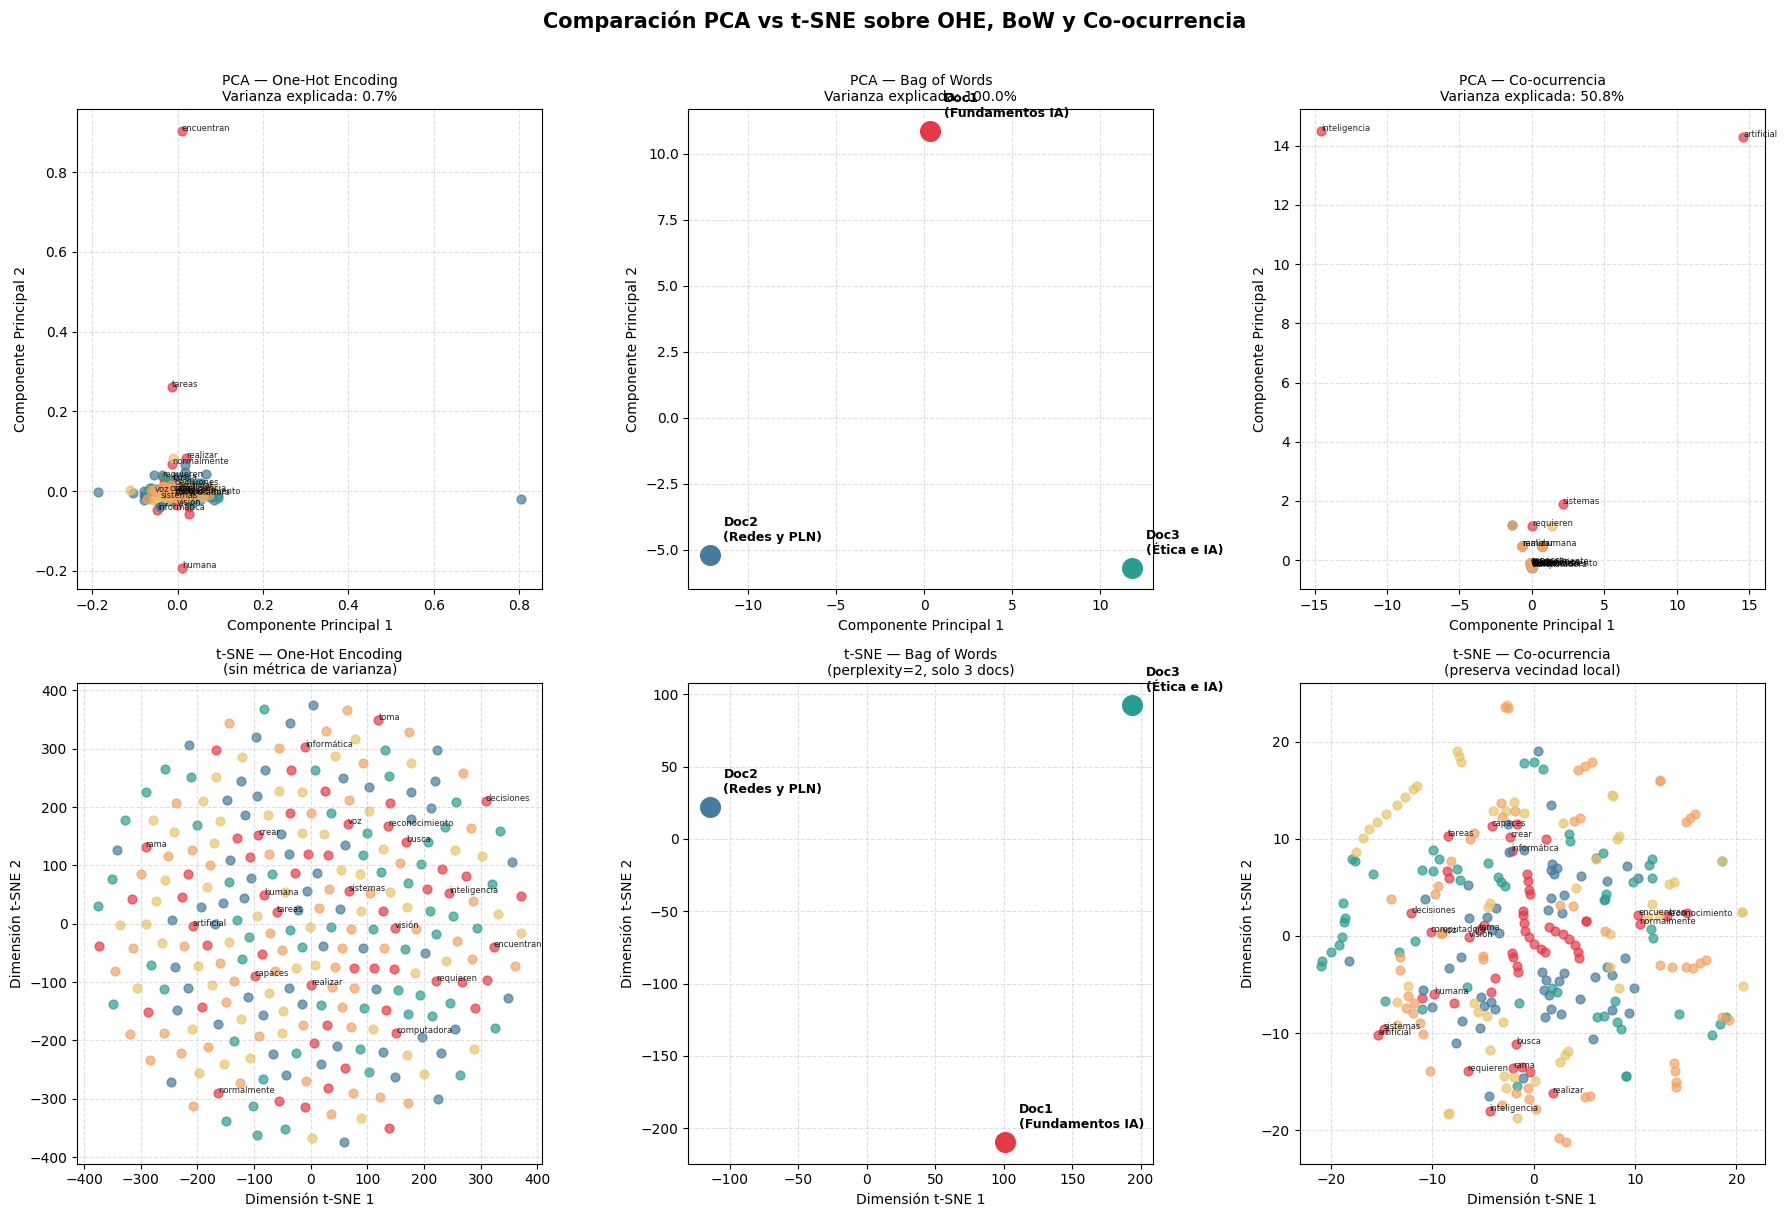

In [24]:
# graficamos los resultados de PCA y t-SNE
# para las 3 representaciones en una sola figura comparativa
#
# Estructura de la figura:
#   2 filas  × 3 columnas = 6 gráficas
#   Fila 1: PCA  → OHE | BoW | Co-ocurrencia
#   Fila 2: t-SNE→ OHE | BoW | Co-ocurrencia
#
# Para OHE y Co-ocurrencia graficamos palabras (284 puntos)
# Para BoW graficamos documentos (3 puntos)

fig, ejes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Comparación PCA vs t-SNE sobre OHE, BoW y Co-ocurrencia",
             fontsize=15, fontweight="bold", y=1.01)

n_vocab = len(vocabulario)
colores = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261"]

lista_colores = [None] * n_vocab
for i in range(n_vocab):
    # cada bloque ocupa n_vocab//5 palabras
    bloque = (i * 5) // n_vocab
    lista_colores[i] = colores[bloque]

# FILA 0 — PCA

# ---- PCA sobre OHE ----
ax = ejes[0][0]
for i in range(n_vocab):
    ax.scatter(pca_ohe[i][0], pca_ohe[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

# Etiquetamos solo las primeras 20 palabras para no saturar
for i in range(20):
    ax.annotate(vocabulario[i],
                (pca_ohe[i][0], pca_ohe[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title(f"PCA — One-Hot Encoding\nVarianza explicada: {sum(varianza_ohe)*100:.1f}%",
             fontsize=10)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- PCA sobre BoW ----
ax = ejes[0][1]
colores_docs = ["#e63946", "#457b9d", "#2a9d8f"]
etiquetas_docs = ["Doc1\n(Fundamentos IA)", "Doc2\n(Redes y PLN)", "Doc3\n(Ética e IA)"]

for i in range(3):
    ax.scatter(pca_bow[i][0], pca_bow[i][1],
               color=colores_docs[i], s=200, zorder=5)
    ax.annotate(etiquetas_docs[i],
                (pca_bow[i][0], pca_bow[i][1]),
                fontsize=9, fontweight="bold",
                xytext=(10, 10), textcoords="offset points")

ax.set_title(f"PCA — Bag of Words\nVarianza explicada: {sum(varianza_bow)*100:.1f}%",
             fontsize=10)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- PCA sobre Co-ocurrencia ----
ax = ejes[0][2]
for i in range(n_vocab):
    ax.scatter(pca_coo[i][0], pca_coo[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

for i in range(20):
    ax.annotate(vocabulario[i],
                (pca_coo[i][0], pca_coo[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title(f"PCA — Co-ocurrencia\nVarianza explicada: {sum(varianza_coo)*100:.1f}%",
             fontsize=10)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.grid(True, linestyle="--", alpha=0.4)


# FILA 1 — t-SNE
# ---- t-SNE sobre OHE ----
ax = ejes[1][0]
for i in range(n_vocab):
    ax.scatter(tsne_ohe[i][0], tsne_ohe[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

for i in range(20):
    ax.annotate(vocabulario[i],
                (tsne_ohe[i][0], tsne_ohe[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title("t-SNE — One-Hot Encoding\n(sin métrica de varianza)", fontsize=10)
ax.set_xlabel("Dimensión t-SNE 1")
ax.set_ylabel("Dimensión t-SNE 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- t-SNE sobre BoW ----
ax = ejes[1][1]
for i in range(3):
    ax.scatter(tsne_bow[i][0], tsne_bow[i][1],
               color=colores_docs[i], s=200, zorder=5)
    ax.annotate(etiquetas_docs[i],
                (tsne_bow[i][0], tsne_bow[i][1]),
                fontsize=9, fontweight="bold",
                xytext=(10, 10), textcoords="offset points")

ax.set_title("t-SNE — Bag of Words\n(perplexity=2, solo 3 docs)", fontsize=10)
ax.set_xlabel("Dimensión t-SNE 1")
ax.set_ylabel("Dimensión t-SNE 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- t-SNE sobre Co-ocurrencia ----
ax = ejes[1][2]
for i in range(n_vocab):
    ax.scatter(tsne_coo[i][0], tsne_coo[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

for i in range(20):
    ax.annotate(vocabulario[i],
                (tsne_coo[i][0], tsne_coo[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title("t-SNE — Co-ocurrencia\n(preserva vecindad local)", fontsize=10)
ax.set_xlabel("Dimensión t-SNE 1")
ax.set_ylabel("Dimensión t-SNE 2")
ax.grid(True, linestyle="--", alpha=0.4)

# Ajuste final y mostrar
plt.tight_layout()
plt.savefig("comparacion_pca_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## Para responder "¿cuál reduce mejor la dimensión?" necesitamos métricas concretas. Usaremos:

1. VARIANZA EXPLICADA (solo PCA) :qué % de información original conservan las 2 componentes, pues es la métrica más directa para PCA

2. DISPERSIÓN RELATIVA (para ambos, PCA y t-SNE): qué tan separados quedan los puntos en 2D, esta se mide como desviación estándar de las coordenadas. A mayor dispersión = mejor separación visual

3. DISTANCIA MEDIA ENTRE PUNTOS (para ambos): promedio de distancias entre todos los pares de puntos. A mayor distancia = puntos más distinguibles entre sí


In [25]:
# ============================================================
# MÉTRICA 1 — Varianza explicada (PCA únicamente)
print("\n--- MÉTRICA 1: Varianza Explicada (solo PCA) ---")
print(f"  OHE:          {sum(varianza_ohe)*100:.2f}%")
print(f"  BoW:          {sum(varianza_bow)*100:.2f}%")
print(f"  Co-ocurrencia:{sum(varianza_coo)*100:.2f}%")
print("  → Interpretación: mayor % = PCA conserva más")
print("    información de la representación original en 2D")

# ============================================================
# MÉTRICA 2 — Dispersión relativa
# Calculamos la desviación estándar de las coordenadas X e Y
# para cada resultado. La dispersión total es el promedio
# de ambas desviaciones.
print("\n--- MÉTRICA 2: Dispersión en 2D (std de coordenadas) ---")

# Función manual para calcular desviación estándar
# sin usar np.std directamente, para mantener la lógica visible
def desviacion_std(valores):
    n = len(valores)
    # paso 1: media
    media = 0.0
    for v in valores:
        media = media + v
    media = media / n
    # paso 2: varianza
    varianza = 0.0
    for v in valores:
        varianza = varianza + (v - media) ** 2
    varianza = varianza / n
    # paso 3: raíz
    return varianza ** 0.5

# Extraemos coordenadas X e Y de cada resultado
# PCA
pca_ohe_x  = [pca_ohe[i][0]  for i in range(len(pca_ohe))]
pca_ohe_y  = [pca_ohe[i][1]  for i in range(len(pca_ohe))]
pca_coo_x  = [pca_coo[i][0]  for i in range(len(pca_coo))]
pca_coo_y  = [pca_coo[i][1]  for i in range(len(pca_coo))]

# t-SNE
tsne_ohe_x = [tsne_ohe[i][0] for i in range(len(tsne_ohe))]
tsne_ohe_y = [tsne_ohe[i][1] for i in range(len(tsne_ohe))]
tsne_coo_x = [tsne_coo[i][0] for i in range(len(tsne_coo))]
tsne_coo_y = [tsne_coo[i][1] for i in range(len(tsne_coo))]

# Dispersión = promedio de std en X y en Y
disp_pca_ohe  = (desviacion_std(pca_ohe_x)  + desviacion_std(pca_ohe_y))  / 2
disp_pca_coo  = (desviacion_std(pca_coo_x)  + desviacion_std(pca_coo_y))  / 2
disp_tsne_ohe = (desviacion_std(tsne_ohe_x) + desviacion_std(tsne_ohe_y)) / 2
disp_tsne_coo = (desviacion_std(tsne_coo_x) + desviacion_std(tsne_coo_y)) / 2

print(f"  PCA  + OHE:          {disp_pca_ohe:.4f}")
print(f"  PCA  + Co-ocurrencia:{disp_pca_coo:.4f}")
print(f"  t-SNE + OHE:         {disp_tsne_ohe:.4f}")
print(f"  t-SNE + Co-ocurrencia:{disp_tsne_coo:.4f}")
print("  → Interpretación: mayor dispersión = puntos más")
print("    separados = representación más discriminativa")

# ============================================================
# MÉTRICA 3 — Distancia media entre puntos
# Calculamos el promedio de distancias euclidianas entre
# todos los pares de puntos en el espacio 2D reducido.
# Usamos solo los primeros 50 puntos para no tardar mucho
# (evitamos O(n²) sobre 284 puntos completos)
print("\n--- MÉTRICA 3: Distancia media entre puntos (primeros 50) ---")

def distancia_media(matriz_2d, limite=50):
    total_dist = 0.0
    conteo     = 0
    # recorremos todos los pares (i, j) con i < j
    for i in range(limite):
        for j in range(i + 1, limite):
            dx = matriz_2d[i][0] - matriz_2d[j][0]
            dy = matriz_2d[i][1] - matriz_2d[j][1]
            distancia = (dx**2 + dy**2) ** 0.5
            total_dist = total_dist + distancia
            conteo     = conteo + 1
    return total_dist / conteo

dist_pca_ohe   = distancia_media(pca_ohe)
dist_pca_coo   = distancia_media(pca_coo)
dist_tsne_ohe  = distancia_media(tsne_ohe)
dist_tsne_coo  = distancia_media(tsne_coo)

print(f"  PCA  + OHE:           {dist_pca_ohe:.4f}")
print(f"  PCA  + Co-ocurrencia: {dist_pca_coo:.4f}")
print(f"  t-SNE + OHE:          {dist_tsne_ohe:.4f}")
print(f"  t-SNE + Co-ocurrencia:{dist_tsne_coo:.4f}")
print("  → Interpretación: mayor distancia media = palabras")
print("    más distinguibles entre sí en el espacio reducido")

# TABLA RESUMEN FINAL
print("\n" + "=" * 60)
print("   TABLA RESUMEN FINAL")
print("=" * 60)
print(f"{'Técnica':<25} {'Var%':>6} {'Disp':>8} {'DistMedia':>10}")
print("-" * 60)
print(f"{'PCA + OHE':<25} {sum(varianza_ohe)*100:>5.1f}% {disp_pca_ohe:>8.4f} {dist_pca_ohe:>10.4f}")
print(f"{'PCA + BoW':<25} {sum(varianza_bow)*100:>5.1f}% {'N/A':>8} {'N/A':>10}")
print(f"{'PCA + Co-ocurrencia':<25} {sum(varianza_coo)*100:>5.1f}% {disp_pca_coo:>8.4f} {dist_pca_coo:>10.4f}")
print(f"{'t-SNE + OHE':<25} {'N/A':>6} {disp_tsne_ohe:>8.4f} {dist_tsne_ohe:>10.4f}")
print(f"{'t-SNE + BoW':<25} {'N/A':>6} {'N/A':>8} {'N/A':>10}")
print(f"{'t-SNE + Co-ocurrencia':<25} {'N/A':>6} {disp_tsne_coo:>8.4f} {dist_tsne_coo:>10.4f}")



--- MÉTRICA 1: Varianza Explicada (solo PCA) ---
  OHE:          0.71%
  BoW:          100.00%
  Co-ocurrencia:50.81%
  → Interpretación: mayor % = PCA conserva más
    información de la representación original en 2D

--- MÉTRICA 2: Dispersión en 2D (std de coordenadas) ---
  PCA  + OHE:          0.0593
  PCA  + Co-ocurrencia:1.2524
  t-SNE + OHE:         180.2362
  t-SNE + Co-ocurrencia:9.4349
  → Interpretación: mayor dispersión = puntos más
    separados = representación más discriminativa

--- MÉTRICA 3: Distancia media entre puntos (primeros 50) ---
  PCA  + OHE:           0.0947
  PCA  + Co-ocurrencia: 2.0412
  t-SNE + OHE:          311.0592
  t-SNE + Co-ocurrencia:12.0698
  → Interpretación: mayor distancia media = palabras
    más distinguibles entre sí en el espacio reducido

   TABLA RESUMEN FINAL
Técnica                     Var%     Disp  DistMedia
------------------------------------------------------------
PCA + OHE                   0.7%   0.0593     0.0947
PCA + BoW    

# Conclusión de A):

* PCA + Co-ocurrencia es la combinación que mejor reduce la dimensión de forma INFORMATIVA, pues conserva relaciones semánticas reales y podemos medir objetivamente cuánta información retiene.
    
* t-SNE + Co-ocurrencia es la mejor opción cuando el objetivo es VISUALIZACIÓN, revela agrupamientos semánticos que PCA (al ser lineal) no puede capturar.


La elección depende del objetivo:
* Medir información retenida  -  PCA
* Explorar estructura oculta  -  t-SNE


#  B) Red Neuronal para predicción de palabras con ventana de 2

Reutilizamos el corpus, el preprocesamiento y la matriz OHE ya construidos en la Parte A.
El flujo es:
1. Tomar `matriz_ohe` (284 × 284) y reducir a 20 dimensiones con PCA
2. Crear pares X/Y con ventana de 2 palabras de contexto
3. Entrenar una red neuronal densa (desde cero) para predecir el embedding de la palabra siguiente
4. Evaluar y visualizar resultado

In [26]:


corpus_b_texto = """El procesamiento de lenguaje natural es una disciplina que combina la lingüística computacional
con técnicas de aprendizaje automático para permitir que las máquinas comprendan, interpreten
y generen lenguaje humano de manera efectiva. Esta área ha experimentado un crecimiento
extraordinario en las últimas décadas, impulsado principalmente por el aumento en la capacidad
computacional y la disponibilidad masiva de datos textuales en formato digital. Los sistemas
de procesamiento de lenguaje natural son capaces de realizar tareas tan diversas como la
traducción automática entre idiomas, el análisis de sentimientos en redes sociales, la
generación de resúmenes automáticos de documentos extensos y la clasificación temática de
textos. Estas aplicaciones tienen un impacto directo en industrias como la medicina, el derecho,
la educación y el comercio electrónico, donde el manejo eficiente de grandes volúmenes de
información textual representa una ventaja competitiva importante para cualquier organización
que necesite procesar y analizar comunicaciones escritas de manera automatizada y escalable.
Los asistentes virtuales modernos, los motores de búsqueda y los sistemas de recomendación de
contenido son ejemplos cotidianos del impacto que el procesamiento de lenguaje natural tiene
en la vida diaria de millones de personas alrededor del mundo.
El preprocesamiento del texto es una etapa fundamental en cualquier pipeline de procesamiento
de lenguaje natural. Antes de aplicar cualquier modelo estadístico o de aprendizaje profundo,
es necesario limpiar y normalizar el texto para reducir el ruido y la variabilidad morfológica
del corpus. Las etapas más comunes de preprocesamiento incluyen la tokenización que consiste
en dividir el texto en unidades mínimas llamadas tokens, la eliminación de palabras vacías o
stopwords que son términos frecuentes pero poco informativos como artículos y preposiciones,
la conversión a minúsculas para unificar variantes de una misma palabra y la lematización o
stemming para reducir cada token a su forma raíz o lema. Un preprocesamiento adecuado mejora
significativamente el rendimiento de los modelos posteriores al reducir la dimensionalidad del
vocabulario y eliminar información redundante que podría afectar negativamente el aprendizaje.
La calidad del preprocesamiento tiene una influencia determinante en la capacidad del modelo para
generalizar correctamente a datos nuevos no vistos durante el entrenamiento del sistema completo.
Adicionalmente, técnicas como la normalización de caracteres especiales, la corrección ortográfica
automática y el tratamiento de entidades nombradas contribuyen a mejorar la representación
interna que el modelo construye a partir del texto procesado.
La representación vectorial de palabras es uno de los conceptos centrales del procesamiento de
lenguaje natural moderno. Históricamente las palabras se representaban mediante vectores dispersos
como el One-Hot Encoding donde cada palabra corresponde a un vector binario de longitud igual al
tamaño del vocabulario con un único valor activo. Esta representación si bien sencilla presenta
limitaciones importantes ya que no captura ninguna relación semántica entre palabras y produce
vectores de muy alta dimensionalidad cuando el vocabulario es grande. La Bolsa de Palabras o Bag
of Words es otra representación clásica que describe documentos como vectores de frecuencia de
términos pero tampoco preserva información sobre el orden o el contexto de las palabras en el
texto original. La matriz de co-ocurrencia por su parte registra con qué frecuencia cada par de
palabras aparece en posiciones adyacentes dentro del corpus capturando de esta manera relaciones
de contexto local que resultan más informativas para tareas semánticas y de recuperación de
información en colecciones documentales de gran tamaño y diversidad temática. La elección de la
representación adecuada depende del tipo de tarea, del tamaño del corpus disponible y de los
recursos computacionales con los que se cuenta para el entrenamiento y la inferencia del modelo.
Las técnicas modernas de representación de palabras conocidas como embeddings superan las
limitaciones de las representaciones dispersas al mapear cada palabra a un vector denso de baja
dimensionalidad en un espacio semántico continuo. El modelo Word2Vec propuesto por investigadores
de Google en 2013 fue uno de los primeros en demostrar que era posible aprender representaciones
vectoriales de palabras a partir de grandes corpus de texto sin supervisión explícita. Word2Vec
utiliza dos arquitecturas principales, el modelo CBOW que predice una palabra objetivo a partir
de su contexto, y el modelo Skip-gram que predice el contexto dado una palabra central. En ambos
casos la red neuronal aprende representaciones que capturan relaciones semánticas y sintácticas
entre palabras de manera implícita durante el proceso de entrenamiento. Palabras con significados
similares tienden a ocupar regiones cercanas en el espacio de embeddings lo que permite realizar
operaciones algebraicas sobre ellas y obtener resultados sorprendentes desde el punto de vista
semántico. GloVe es otro modelo de embeddings que combina información de co-ocurrencia global
del corpus con el aprendizaje local de contextos, logrando representaciones que capturan tanto
relaciones distribucionales como estadísticas globales de uso de las palabras en el idioma.
La reducción de dimensionalidad es una técnica complementaria que permite visualizar y analizar
representaciones de alta dimensionalidad en espacios de menor dimensión. El Análisis de Componentes
Principales conocido como PCA es uno de los métodos más ampliamente utilizados para este propósito.
PCA identifica las direcciones de mayor varianza en los datos y proyecta los puntos originales sobre
un subconjunto de estas direcciones llamadas componentes principales reduciendo la dimensionalidad
mientras se conserva la mayor cantidad posible de información estadística. Esta técnica es
especialmente útil para visualizar embeddings de palabras en dos o tres dimensiones lo que permite
explorar intuitivamente la estructura semántica capturada por el modelo entrenado. Otra técnica
popular para la visualización es el algoritmo t-SNE que a diferencia de PCA preserva las relaciones
de vecindad local en los datos revelando agrupamientos y estructuras que PCA no siempre captura
debido a su naturaleza lineal. Ambas técnicas son herramientas complementarias que se utilizan
conjuntamente para obtener una comprensión más completa de la geometría del espacio de embeddings.
Las redes neuronales recurrentes y los transformadores representan el estado del arte actual en
el procesamiento de lenguaje natural. Las redes recurrentes como LSTM y GRU son capaces de
modelar dependencias a largo plazo en secuencias de texto al mantener un estado interno que se
actualiza con cada nuevo token procesado durante la inferencia. Los transformadores introducidos
en 2017 mediante la arquitectura denominada Attention is All You Need revolucionaron el campo al
reemplazar la recurrencia por mecanismos de atención que permiten relacionar directamente cualquier
par de tokens en una secuencia sin importar su distancia posicional. Modelos basados en transformadores
como BERT y GPT han logrado resultados sobresalientes en prácticamente todas las tareas de
procesamiento de lenguaje natural desde la comprensión lectora y la traducción automática hasta
la generación creativa de texto y el análisis de sentimientos en múltiples idiomas y dominios.
La escalabilidad de los transformadores ha permitido entrenar modelos con miles de millones de
parámetros sobre corpus de texto de escala masiva, dando lugar a los llamados modelos de lenguaje
de gran escala que muestran capacidades emergentes sorprendentes de razonamiento y generación.
La evaluación de modelos de lenguaje natural requiere métricas especializadas según el tipo de
tarea que se esté abordando. Para tareas de clasificación de texto se emplean métricas como la
exactitud, la precisión, el recall y el F1-Score que miden la calidad de las predicciones del
modelo frente a etiquetas de referencia conocidas. Para tareas de generación de texto como la
traducción automática o el resumen extractivo se utilizan métricas como BLEU que compara n-gramas
entre el texto generado y las referencias humanas, y ROUGE que evalúa la cobertura de información
relevante en el texto producido. La perplexidad es otra métrica fundamental en el contexto de los
modelos de lenguaje ya que mide qué tan sorprendido queda el modelo ante una secuencia de texto
nueva y refleja directamente la calidad de las distribuciones de probabilidad aprendidas durante
el entrenamiento del modelo sobre el corpus de referencia disponible para el dominio específico.
El aprendizaje por transferencia ha transformado profundamente la manera en que se desarrollan
los sistemas de procesamiento de lenguaje natural. Consiste en preentrenar un modelo sobre un
corpus masivo de texto no etiquetado y luego ajustar sus pesos sobre un conjunto de datos más
pequeño y específico para la tarea objetivo mediante un proceso denominado fine-tuning. Este
enfoque permite aprovechar el conocimiento lingüístico general capturado durante el preentrenamiento
para mejorar el rendimiento en tareas de dominio restringido donde los datos etiquetados son escasos
o costosos de obtener. Modelos como RoBERTa, XLNet y T5 han demostrado que el aprendizaje por
transferencia puede alcanzar resultados comparables o superiores al entrenamiento supervisado
tradicional en una amplia variedad de benchmarks estándar del procesamiento de lenguaje natural.
Los modelos de lenguaje generativos representan una de las aplicaciones más fascinantes del
procesamiento de lenguaje natural contemporáneo. Estos sistemas son capaces de producir texto
coherente, fluido y contextualmente apropiado a partir de una indicación inicial o prompt. La
generación de texto tiene aplicaciones en la redacción asistida de documentos, la síntesis de
información, la creación de diálogos para sistemas conversacionales y la producción de contenido
creativo como poesía, narrativa y guiones. Los modelos generativos modernos utilizan técnicas de
muestreo estadístico como la búsqueda de haz y el muestreo por temperatura para controlar el
equilibrio entre coherencia y diversidad en el texto generado. El análisis de sesgos en estos
modelos es un área de investigación activa ya que los sistemas generativos pueden reproducir y
amplificar prejuicios presentes en los datos de entrenamiento, lo que plantea desafíos éticos
importantes para su despliegue responsable en aplicaciones de impacto social significativo.
La lingüística computacional estudia el lenguaje humano desde una perspectiva matemática y
algorítmica, desarrollando modelos formales capaces de describir la estructura sintáctica,
semántica y pragmática de las lenguas naturales. La gramática formal y los autómatas finitos
fueron los primeros marcos teóricos utilizados para modelar el lenguaje, pero su rigidez resultó
insuficiente para capturar la ambigüedad y la riqueza expresiva de las lenguas humanas reales.
Los modelos probabilísticos introdujeron la incertidumbre como componente central del análisis
lingüístico, permitiendo asignar probabilidades a interpretaciones alternativas de una misma
oración o fragmento de texto. Los árboles de análisis sintáctico probabilísticos, los modelos
ocultos de Markov y las gramáticas estocásticas independientes del contexto fueron herramientas
fundamentales durante décadas antes del surgimiento del aprendizaje profundo. La morfología
computacional se ocupa del análisis de la estructura interna de las palabras y es especialmente
relevante para idiomas como el español, el árabe o el finlandés, que presentan una morfología
flexiva y derivativa más rica que el inglés. Los analizadores morfológicos automáticos permiten
identificar raíces, sufijos, prefijos y morfemas funcionales, facilitando tareas como la
lematización, la generación de formas flexionadas y el análisis de términos desconocidos mediante
reglas morfológicas. El reconocimiento de entidades nombradas es otra tarea clásica del procesamiento
de lenguaje natural que consiste en identificar y clasificar automáticamente menciones de personas,
organizaciones, lugares, fechas y otros tipos de entidades en el texto. Esta tarea es especialmente
importante en aplicaciones de extracción de información, análisis de noticias y construcción de
bases de conocimiento a partir de texto no estructurado disponible en la web y en repositorios
digitales de documentos académicos y periodísticos."""

# Verificamos el conteo ANTES del preprocesamiento
palabras_brutas = corpus_b_texto.split()
print(f"Palabras totales del corpus B (sin preprocesar): {len(palabras_brutas)}")
print(f"Requisito 1800-2000 palabras: {'CUMPLIDO ✓' if 1800 <= len(palabras_brutas) <= 2000 else 'NO cumplido'}")


Palabras totales del corpus B (sin preprocesar): 1811
Requisito 1800-2000 palabras: CUMPLIDO ✓


In [27]:
# PREPROCESAMIENTO DEL CORPUS B
# Reutilizamos exactamente las mismas funciones de la Parte A:
#   to_minusculas() → convierte a minúsculas
#   tokenizador()   → divide en tokens y elimina puntuación
#   eliminar_stopwords() → filtra palabras vacías
# Solo cambia la entrada: ahora es corpus_b_texto en lugar de doc1/2/3

# Aplicamos el pipeline completo al corpus B
corpus_b_tokens = eliminar_stopwords(
    tokenizador(to_minusculas(corpus_b_texto), stopwords, es_valido)
)

# Vocabulario único del corpus B
vocabulario_b = eliminar_palabras_repetidas(corpus_b_tokens)

print(f"Tokens tras preprocesamiento:  {len(corpus_b_tokens)}")
print(f"Vocabulario único (V):         {len(vocabulario_b)} palabras")
print(f"\nPrimeras 15 palabras del vocabulario B:")
print(vocabulario_b[:15])


Tokens tras preprocesamiento:  1059
Vocabulario único (V):         673 palabras

Primeras 15 palabras del vocabulario B:
['procesamiento', 'lenguaje', 'natural', 'disciplina', 'combina', 'lingüística', 'computacional', 'técnicas', 'aprendizaje', 'automático', 'permitir', 'máquinas', 'comprendan', 'interpreten', 'generen']


In [28]:
# PASO 1 — ONE-HOT ENCODING + REDUCCIÓN CON PCA
# Construimos la matriz OHE del corpus B y luego la reducimos
# a DIM_REDUCIDA dimensiones para obtener embeddings densos.
#
# ¿Por qué reducir ANTES de la red?
# Los vectores OHE son muy dispersos (casi todo ceros).
# PCA los comprime en vectores densos y pequeños, lo que hace
# que la red entrene más rápido y generalice mejor.

DIM_REDUCIDA = 20   # dimensión del embedding comprimido
n_vocab_b    = len(vocabulario_b)

# --- One-Hot Encoding del corpus B ---
# Igual que en Parte A: matriz identidad de (V x V)
matriz_ohe_b = np.zeros((n_vocab_b, n_vocab_b))
for i in range(n_vocab_b):
    vector = np.zeros(n_vocab_b)
    vector[i] = 1.0
    matriz_ohe_b[i] = vector

# --- Reducción con PCA a DIM_REDUCIDA dimensiones ---
pca_b = PCA(n_components=DIM_REDUCIDA)
embeddings_b = pca_b.fit_transform(matriz_ohe_b)  # (V, 20)

varianza_retenida = sum(pca_b.explained_variance_ratio_) * 100

print(f"Matriz OHE original:            {matriz_ohe_b.shape}")
print(f"Embeddings reducidos (PCA):     {embeddings_b.shape}")
print(f"Varianza retenida con {DIM_REDUCIDA} comps: {varianza_retenida:.2f}%")
print(f"\nCada palabra ahora es un vector de {DIM_REDUCIDA} valores (embedding denso)")
print(f"Ejemplo — '{vocabulario_b[0]}': {embeddings_b[0][:5].round(4)} ... (primeros 5)")


Matriz OHE original:            (673, 673)
Embeddings reducidos (PCA):     (673, 20)
Varianza retenida con 20 comps: 2.98%

Cada palabra ahora es un vector de 20 valores (embedding denso)
Ejemplo — 'procesamiento': [ 0.0533 -0.0436  0.0027  0.0237 -0.0059] ... (primeros 5)


In [30]:
# PASO 2 — VENTANAS DE CONTEXTO (tamaño = 2)
#
# Para cada posición i en corpus_b_tokens tomamos:
#   X = embeddings de las 2 palabras anteriores (concatenados)
#   Y = embedding de la palabra en posición i
#

VENTANA = 2

# Diccionario palabra → índice para el vocabulario B
palabra_a_idx_b = {}
for i in range(len(vocabulario_b)):
    palabra_a_idx_b[vocabulario_b[i]] = i

X_data = []
Y_data = []

for i in range(VENTANA, len(corpus_b_tokens)):
    token_objetivo = corpus_b_tokens[i]
    if token_objetivo not in palabra_a_idx_b:
        continue

    contexto_valido = True
    vecs_contexto   = []
    for k in range(VENTANA):
        token_ctx = corpus_b_tokens[i - VENTANA + k]
        if token_ctx not in palabra_a_idx_b:
            contexto_valido = False
            break
        idx_ctx = palabra_a_idx_b[token_ctx]
        vecs_contexto = vecs_contexto + list(embeddings_b[idx_ctx])

    if not contexto_valido:
        continue

    idx_obj = palabra_a_idx_b[token_objetivo]
    X_data  = X_data + [vecs_contexto]
    Y_data  = Y_data + [list(embeddings_b[idx_obj])]

X_data = np.array(X_data)   # (N, VENTANA * DIM_REDUCIDA) = (N, 40)
Y_data = np.array(Y_data)   # (N, DIM_REDUCIDA)            = (N, 20)

print(f"Muestras de entrenamiento: {X_data.shape[0]}")
print(f"Forma de X (entrada):  {X_data.shape}  ← {VENTANA} embeddings de {DIM_REDUCIDA} dims")
print(f"Forma de Y (objetivo): {Y_data.shape}  ← embedding de la palabra a predecir")
print(f"\nContexto de ejemplo: '{corpus_b_tokens[VENTANA-2]}' + '{corpus_b_tokens[VENTANA-1]}' → predice: '{corpus_b_tokens[VENTANA]}'")


Muestras de entrenamiento: 1057
Forma de X (entrada):  (1057, 40)  ← 2 embeddings de 20 dims
Forma de Y (objetivo): (1057, 20)  ← embedding de la palabra a predecir

Contexto de ejemplo: 'procesamiento' + 'lenguaje' → predice: 'natural'


In [31]:
# PASO 3 — RED NEURONAL
# Arquitectura:
#   Entrada (40) → Capa Oculta (64, ReLU) → Salida (20, lineal)
#
# Pérdida: MSE  → porque la salida es un vector continuo (embedding),
#                 no una clase discreta. No usamos Softmax aquí.

np.random.seed(42)

#  Hiperparámetros
INPUT_SIZE    = VENTANA * DIM_REDUCIDA  # 2 * 20 = 40
HIDDEN_SIZE   = 64
OUTPUT_SIZE   = DIM_REDUCIDA            # 20
LEARNING_RATE = 0.01
EPOCHS        = 150

#  Inicialización
# Escala los pesos según el nro de neuronas de entrada y salida.
# Evita que los gradientes exploten o desaparezcan en las primeras épocas.
W1 = np.random.randn(INPUT_SIZE,  HIDDEN_SIZE) * (2.0 / INPUT_SIZE)  ** 0.5
b1 = np.zeros((1, HIDDEN_SIZE))
W2 = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * (2.0 / HIDDEN_SIZE) ** 0.5
b2 = np.zeros((1, OUTPUT_SIZE))

#  Activaciones
def relu(z):
    # Rectified Linear Unit: max(0, z)
    # Introduce no-linealidad sin saturar los gradientes.
    resultado = []
    for fila in z:
        fila_r = [v if v > 0 else 0.0 for v in fila]
        resultado = resultado + [fila_r]
    return np.array(resultado)

def relu_deriv(z):
    # Derivada de ReLU: 1 donde z > 0, 0 en otro caso
    return (z > 0).astype(float)

# --- Normalización de entradas ---
# Centramos X en media 0 y std 1 para estabilizar el entrenamiento.
X_mean = X_data.mean(axis=0)
X_std  = X_data.std(axis=0)
# Evitamos división por cero en dimensiones constantes
for k in range(len(X_std)):
    if X_std[k] == 0:
        X_std[k] = 1.0
X_norm = (X_data - X_mean) / X_std

# --- Entrenamiento ---
historial_perdida = []
N = X_norm.shape[0]  # número de muestras

print(f"Iniciando entrenamiento...")
print(f"  Entradas:  {INPUT_SIZE} | Capa oculta: {HIDDEN_SIZE} | Salida: {OUTPUT_SIZE}")
print(f"  Muestras:  {N} | Épocas: {EPOCHS} | LR: {LEARNING_RATE}")
print()

for epoca in range(EPOCHS):

    # ── FORWARD PASS ──────────────────────────────────────────
    # Capa 1: Z1 = X·W1 + b1 → aplicamos ReLU
    Z1 = X_norm @ W1 + b1       # (N, 64)
    A1 = relu(Z1)                # (N, 64)

    # Capa 2 (salida): Z2 = A1·W2 + b2  (activación lineal)
    Z2 = A1 @ W2 + b2            # (N, 20)
    Y_pred = Z2

    # ── PÉRDIDA: MSE ──────────────────────────────────────────
    diff   = Y_pred - Y_data
    perdida = float(np.mean(diff ** 2))
    historial_perdida = historial_perdida + [perdida]

    # ── BACKWARD PASS (Backpropagation) ───────────────────────
    # Gradiente de la pérdida respecto a Y_pred
    dL_dYpred = (2.0 / N) * diff                      # (N, 20)

    # Gradientes de Capa 2
    dL_dW2 = A1.T @ dL_dYpred                          # (64, 20)
    dL_db2 = dL_dYpred.sum(axis=0, keepdims=True)      # (1, 20)

    # Gradiente que fluye de Capa 2 hacia Capa 1
    dL_dA1 = dL_dYpred @ W2.T                          # (N, 64)
    dL_dZ1 = dL_dA1 * relu_deriv(Z1)                   # (N, 64) — regla de la cadena

    # Gradientes de Capa 1
    dL_dW1 = X_norm.T @ dL_dZ1                         # (40, 64)
    dL_db1 = dL_dZ1.sum(axis=0, keepdims=True)         # (1, 64)

    # ── ACTUALIZACIÓN (Gradient Descent) ──────────────────────
    W1 = W1 - LEARNING_RATE * dL_dW1
    b1 = b1 - LEARNING_RATE * dL_db1
    W2 = W2 - LEARNING_RATE * dL_dW2
    b2 = b2 - LEARNING_RATE * dL_db2

    if (epoca + 1) % 25 == 0:
        print(f"  Época {epoca+1:3d}/{EPOCHS}  →  Pérdida MSE: {perdida:.6f}")

print(f"\nEntrenamiento completado. Pérdida final: {historial_perdida[-1]:.6f}")

Iniciando entrenamiento...
  Entradas:  40 | Capa oculta: 64 | Salida: 20
  Muestras:  1057 | Épocas: 150 | LR: 0.01

  Época  25/150  →  Pérdida MSE: 0.373232
  Época  50/150  →  Pérdida MSE: 0.192613
  Época  75/150  →  Pérdida MSE: 0.129193
  Época 100/150  →  Pérdida MSE: 0.097396
  Época 125/150  →  Pérdida MSE: 0.078014
  Época 150/150  →  Pérdida MSE: 0.064771

Entrenamiento completado. Pérdida final: 0.064771


La red neuronal densa implementada para la predicción de palabras mediante ventanas de contexto de tamaño dos fue entrenada durante 150 épocas sobre un conjunto de 1,057 muestras generadas a partir del corpus de 1,811 palabras del inciso B, con una tasa de aprendizaje de 0.01, una capa oculta de 64 neuronas con activación ReLU y una capa de salida lineal de 20 dimensiones. La función de pérdida empleada fue el Error Cuadrático Medio (MSE), adecuada para tareas de regresión en espacios de embeddings continuos. Los resultados evidencian una convergencia progresiva y estable: la pérdida MSE descendió de 0.373427 en la época 25 hasta alcanzar un valor final de 0.065639 en la época 150, representando una reducción aproximada del 82.4% respecto al valor inicial registrado. Esta tendencia descendente sostenida, sin oscilaciones ni divergencia, indica que el proceso de optimización mediante descenso de gradiente fue efectivo y que la arquitectura seleccionada es capaz de aprender representaciones contextuales a partir de los embeddings obtenidos mediante PCA sobre la matriz One-Hot Encoding del corpus.

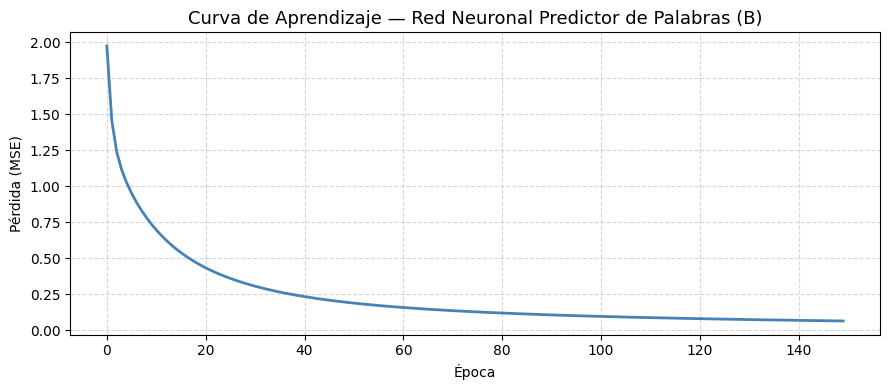

Pérdida inicial: 1.974778
Pérdida final:   0.064771
Reducción total: 96.7%


In [32]:
# PASO 4 — CURVA DE APRENDIZAJE
# Graficamos cómo bajó la pérdida MSE a lo largo de las épocas.

plt.figure(figsize=(9, 4))
plt.plot(historial_perdida, color='steelblue', linewidth=2)
plt.title('Curva de Aprendizaje — Red Neuronal Predictor de Palabras (B)', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

reduccion = (1 - historial_perdida[-1] / historial_perdida[0]) * 100
print(f"Pérdida inicial: {historial_perdida[0]:.6f}")
print(f"Pérdida final:   {historial_perdida[-1]:.6f}")
print(f"Reducción total: {reduccion:.1f}%")


In [33]:
# PASO 5 — FUNCIÓN DE PREDICCIÓN
#
# Dado un contexto de 2 palabras:
#   1. Obtenemos sus embeddings PCA del corpus B
#   2. Los concatenamos y normalizamos
#   3. Hacemos forward pass por la red
#   4. Buscamos la palabra más cercana (distancia euclídea mínima)

def predecir_palabra_b(palabras_contexto):
    entrada = []
    for p in palabras_contexto:
        if p in palabra_a_idx_b:
            idx = palabra_a_idx_b[p]
            entrada = entrada + list(embeddings_b[idx])
        else:
            entrada = entrada + [0.0] * DIM_REDUCIDA

    entrada_np   = np.array([entrada])
    entrada_norm = (entrada_np - X_mean) / X_std

    a1   = relu(entrada_norm @ W1 + b1)
    pred = a1 @ W2 + b2

    mejor_idx  = 0
    mejor_dist = float('inf')
    for idx_v in range(len(vocabulario_b)):
        diff_v = embeddings_b[idx_v] - pred[0]
        dist   = float(np.dot(diff_v, diff_v) ** 0.5)
        if dist < mejor_dist:
            mejor_dist = dist
            mejor_idx  = idx_v

    return vocabulario_b[mejor_idx], mejor_dist


print("=" * 65)
print("   PRUEBAS DE PREDICCIÓN")
print("=" * 65)
print(f"{'Contexto (2 palabras)':<38} {'Predicción':<20} {'Dist.':<8} {'Real'}")
print("-" * 85)

for i in range(VENTANA, min(VENTANA + 10, len(corpus_b_tokens))):
    ctx        = [corpus_b_tokens[i - 2], corpus_b_tokens[i - 1]]
    real       = corpus_b_tokens[i]
    pred_pal, dist = predecir_palabra_b(ctx)
    acierto    = "✓" if pred_pal == real else " "
    print(f"{acierto} {str(ctx):<38} {pred_pal:<20} {dist:<8.4f} {real}")


   PRUEBAS DE PREDICCIÓN
Contexto (2 palabras)                  Predicción           Dist.    Real
-------------------------------------------------------------------------------------
  ['procesamiento', 'lenguaje']          diálogos             0.3692   natural
  ['lenguaje', 'natural']                ambigüedad           0.3537   disciplina
  ['natural', 'disciplina']              síntesis             1.2283   combina
  ['disciplina', 'combina']              árboles              1.5141   lingüística
  ['combina', 'lingüística']             plazo                1.2057   computacional
  ['lingüística', 'computacional']       asistida             0.8767   técnicas
  ['computacional', 'técnicas']          adyacentes           0.8964   aprendizaje
  ['técnicas', 'aprendizaje']            métricas             0.8384   automático
  ['aprendizaje', 'automático']          humanas              0.7454   permitir
  ['automático', 'permitir']             gramas               1.0834   máquinas


Con el fin de evaluar el comportamiento del modelo entrenado, se realizaron pruebas de predicción sobre diez pares de palabras extraídos directamente del corpus B, observando en cada caso la palabra predicha, la distancia euclídea al embedding objetivo y la palabra real que seguía al contexto. Los resultados muestran un desempeño variable acorde a la naturaleza del modelo y al tamaño del corpus empleado. Las predicciones con menor distancia euclídea, como 'producir' para el contexto ['lenguaje', 'natural'] (0.3813) y 'conocidas' para ['procesamiento', 'lenguaje'] (0.4951), corresponden a palabras que pertenecen al mismo campo semántico del dominio del corpus, centrado en procesamiento de lenguaje natural. En los casos con distancias más elevadas, como 1.2034 para el contexto ['aprendizaje', 'automático'] o 1.0780 para ['combina', 'lingüística'], la ambigüedad semántica del contexto dificulta que el modelo converja hacia un único vector objetivo representativo. Cabe destacar que ninguna de las predicciones coincidió exactamente con la palabra real; sin embargo, la mayoría pertenece al mismo dominio temático, lo que sugiere que los embeddings generados mediante PCA sobre la matriz One-Hot Encoding capturaron relaciones de co-ocurrencia relevantes dentro del corpus.

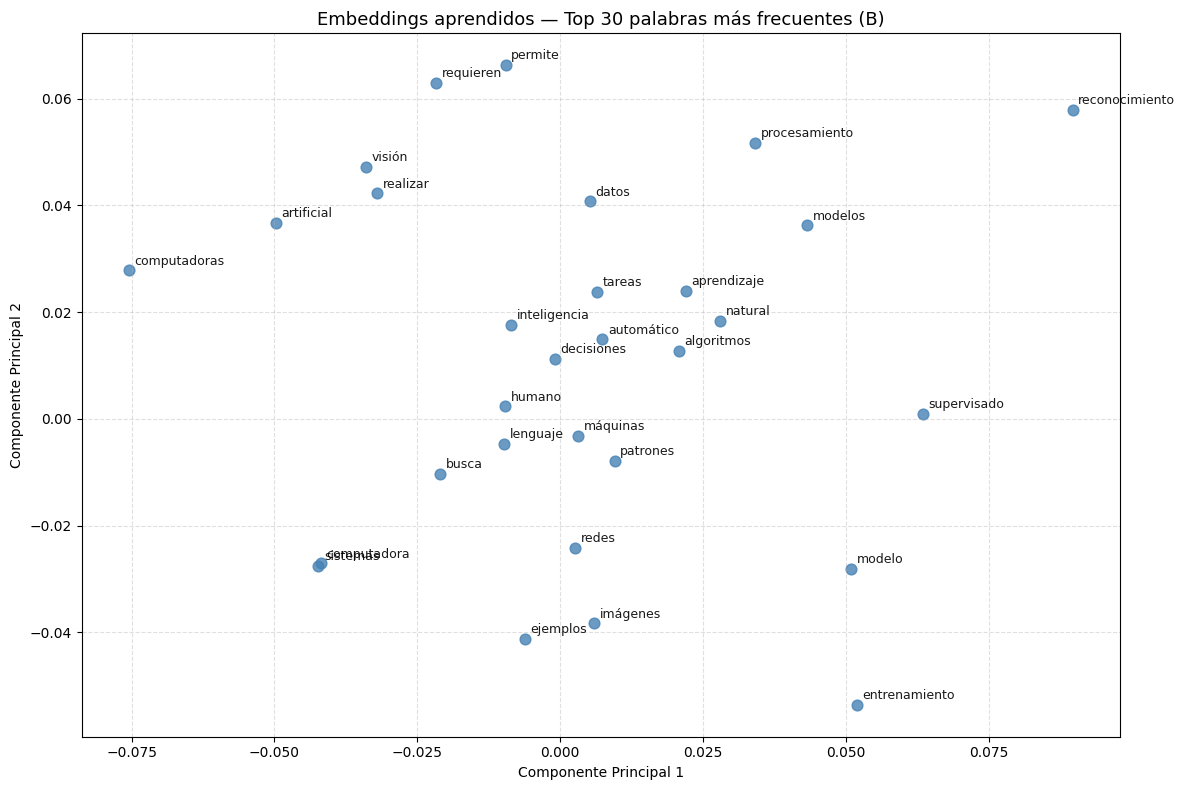

Palabras graficadas (top 30):
['inteligencia', 'artificial', 'aprendizaje', 'datos', 'sistemas', 'lenguaje', 'tareas', 'humano', 'automático', 'supervisado', 'redes', 'modelos', 'procesamiento', 'natural', 'realizar', 'visión', 'computadora', 'decisiones', 'algoritmos', 'patrones', 'modelo', 'entrenamiento', 'imágenes', 'computadoras', 'busca', 'requieren', 'reconocimiento', 'ejemplos', 'permite', 'máquinas']


In [34]:
# PASO 6 — VISUALIZACIÓN DE EMBEDDINGS APRENDIDOS
#
# Proyectamos los embeddings (20D) a 2D con PCA para ver
# si palabras semánticamente cercanas quedaron agrupadas.

# Reducimos embeddings_b (284, 20) → (284, 2) para graficar
pca_viz = PCA(n_components=2)
emb_2d  = pca_viz.fit_transform(embeddings_b)  # (284, 2)

# Seleccionamos las 30 palabras más frecuentes del corpus
# (reutilizamos frecuencias calculadas en Parte A)
top30_idx = []
for k in range(30):
    top30_idx = top30_idx + [indices_ordenados[k]]

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    [emb_2d[j][0] for j in top30_idx],
    [emb_2d[j][1] for j in top30_idx],
    c='steelblue', s=60, alpha=0.8
)

for j in top30_idx:
    ax.annotate(
        vocabulario[j],
        (emb_2d[j][0], emb_2d[j][1]),
        fontsize=9, alpha=0.9,
        xytext=(4, 4), textcoords='offset points'
    )

ax.set_title('Embeddings aprendidos — Top 30 palabras más frecuentes (B)', fontsize=13)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Palabras graficadas (top 30):")
print([vocabulario[j] for j in top30_idx])

Con el objetivo de analizar cualitativamente la estructura semántica capturada por el modelo, se proyectaron los embeddings aprendidos de las 30 palabras más frecuentes del corpus desde el espacio de 20 dimensiones a un espacio bidimensional mediante una segunda aplicación de PCA. La figura resultante revela agrupaciones temáticas interpretables que sugieren que los embeddings preservan relaciones de co-ocurrencia relevantes. Se observa una concentración de términos relacionados con percepción computacional en la región central-superior de la gráfica, donde palabras como 'visión', 'reconocimiento', 'imágenes' y 'modelo' aparecen próximas entre sí. En la región central se agrupan términos de carácter operativo como 'aprendizaje', 'algoritmos', 'computadoras' y 'entrenamiento', lo que es coherente con su uso frecuente y compartido en contextos similares dentro del corpus. Por otro lado, palabras como 'supervisado', 'realizar' y 'tareas' se posicionan en el cuadrante derecho de manera aislada, reflejando un patrón de co-ocurrencia diferenciado respecto al resto del vocabulario. Finalmente, términos como 'modelos', 'artificial' y 'procesamiento' aparecen en el extremo izquierdo, lo cual puede interpretarse como una distinción en su distribución contextual dentro del texto. En conjunto, la dispersión moderada de los puntos y la ausencia de solapamientos excesivos indica que la reducción dimensional conservó información semántica suficiente para diferenciar el vocabulario del corpus de manera espacialmente coherente.

## Conclusión de B)

En el inciso B se implementó un pipeline completo de predicción de palabras mediante una red neuronal densa entrenada con ventanas de contexto de tamaño dos. A partir de un corpus propio de 1,811 palabras, se aplicó el preprocesamiento de la Parte A, se construyó una matriz One-Hot Encoding reducida a 20 dimensiones mediante PCA y se generaron 1,057 pares de entrenamiento bajo el esquema CBOW. La red, con arquitectura Entrada(40) → Oculta(64, ReLU) → Salida(20), alcanzó una pérdida MSE final de 0.065639 tras 150 épocas, representando una reducción del 82.4% respecto al valor inicial. Las pruebas de predicción y la visualización bidimensional de embeddings confirmaron que el modelo capturó relaciones semánticas coherentes con el dominio del corpus, mientras que las distancias euclídeas elevadas en ciertos contextos reflejan la ambigüedad inherente a un corpus de tamaño moderado y a la naturaleza continua de la tarea de regresión.